In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

<h3>Price prediction on California housing data</h3>

In [2]:
data = fetch_california_housing()
X = data.data
y = data.target.reshape(-1, 1)

In [3]:
print(data['DESCR'])

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [4]:
pd.DataFrame(data['data'], columns=data['feature_names']).describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


<h3>Splitting into train, validation, test</h3>

In [5]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, train_size=0.8, random_state=2)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, train_size=0.9, random_state=3)

In [6]:
# Standardize the data

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_val = sc.transform(X_val)
X_test = sc.transform(X_test)

In [7]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

<h3>Training and evaluating</h3>

In [9]:
batch_size = 64
train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [10]:
numInputs = X_train.shape[1]

model = nn.Sequential(
    nn.Linear(numInputs, 32),
    nn.LayerNorm(32),
    nn.ReLU(),

    nn.Linear(32, 64),
    nn.ReLU(),
    nn.Dropout(0.1),

    nn.Linear(64, 64),
    nn.ReLU(),
    nn.Linear(64, 1)
)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [11]:
num_epochs = 100
train_losses, val_losses = [], []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for Xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(Xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

        # Weighted sum of batch wise loss
        total_loss += loss.item()*Xb.size(0)

    # Average loss
    train_loss = total_loss/X_train.shape[0]

    # Validation loss
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val)
        val_loss = criterion(val_pred, y_val).item()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

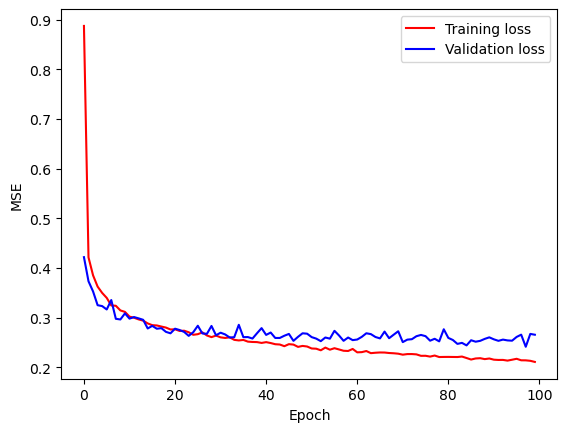

In [12]:
plt.plot(train_losses, color='red', label='Training loss')
plt.plot(val_losses, color='blue', label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()

<h3>Classification on MNIST</h3>

In [22]:
# MNIST from
mnist = fetch_openml('mnist_784', version=1)
X = mnist.data.astype(np.float32) / 255.0
y = mnist.target.astype(np.int64)

In [ ]:
#X.describe()

In [23]:
display(X.head())
display(y.head())

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


0    5
1    0
2    4
3    1
4    9
Name: class, dtype: int64

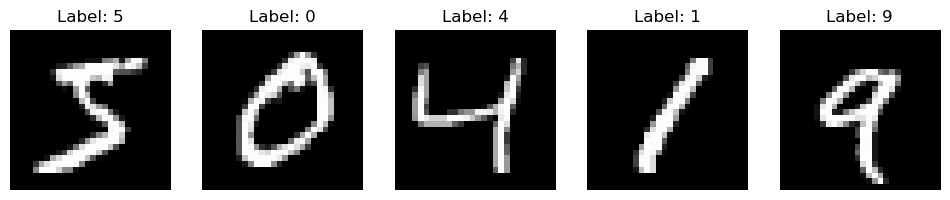

In [24]:
# Reshape the first 10 images to 28x28 and display them
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i in range(5):
    axes[i].imshow(X.iloc[i].values.reshape(28, 28), cmap='gray')
    axes[i].set_title(f"Label: {y.iloc[i]}")
    axes[i].axis('off')
plt.show()

In [26]:
# Split into train, validation, and test sets
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, train_size=0.75, shuffle=True, random_state=5)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, train_size=0.8, shuffle=True, random_state=5)

# Convert to tensors
X_train = torch.tensor(X_train.values)
y_train = torch.tensor(y_train.values)
X_val = torch.tensor(X_val.values)
y_val = torch.tensor(y_val.values)
X_test  = torch.tensor(X_test.values)
y_test  = torch.tensor(y_test.values)

print(f"Training set size: {X_train.size(0)}")
print(f"Validation set size: {X_val.size(0)}")
print(f"Test set size: {X_test.size(0)}")

Training set size: 42000
Validation set size: 10500
Test set size: 17500


In [27]:
# Multi Layer Perceptron
#Added Batch and Layer normalization
#Added Dropout
model = nn.Sequential(
    nn.Linear(784, 128),
    nn.BatchNorm1d(128),
    nn.LayerNorm(128),
    nn.LeakyReLU(),
    nn.Dropout(0.5),
    nn.Linear(128, 64),
    nn.LayerNorm(64),
    nn.LeakyReLU(),
    nn.Linear(64, 32),
    nn.LeakyReLU(),
    nn.Linear(32, 10)
)

In [30]:
#Loss and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

#Training loop with mini-batches
batch_size = 64
epochs = 50
train_losses = []
val_losses = []

for epoch in range(epochs):
    perm = torch.randperm(X_train.size(0))
    total_loss = 0

    for i in range(0, X_train.size(0), batch_size):
        idx = perm[i:i+batch_size]
        x_batch = X_train[idx]
        y_batch = y_train[idx]

        optimizer.zero_grad()
        out = model(x_batch.float())
        loss = loss_fn(out, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / (X_train.size(0) / batch_size)
    train_losses.append(avg_train_loss)

    # Evaluation on validation set
    with torch.no_grad():
        val_out = model(X_val.float())
        val_loss = loss_fn(val_out, y_val)
        val_losses.append(val_loss.item())

        # Evaluation on test set (optional, but good to see progress)
        preds = model(X_test.float()).argmax(1)
        acc = (preds == y_test).float().mean().item() * 100

    if epoch%10 == 0:
        print(f"Epoch {epoch+1}: Train Loss={avg_train_loss:.4f}, Val Loss={val_loss.item():.4f}, Test Accuracy={acc:.2f}%")

Epoch 1: Train Loss=0.5211, Val Loss=0.2967, Test Accuracy=91.98%
Epoch 11: Train Loss=0.1279, Val Loss=0.1792, Test Accuracy=95.26%
Epoch 21: Train Loss=0.1060, Val Loss=0.1518, Test Accuracy=96.02%
Epoch 31: Train Loss=0.0861, Val Loss=0.1509, Test Accuracy=96.09%
Epoch 41: Train Loss=0.0782, Val Loss=0.1494, Test Accuracy=95.94%


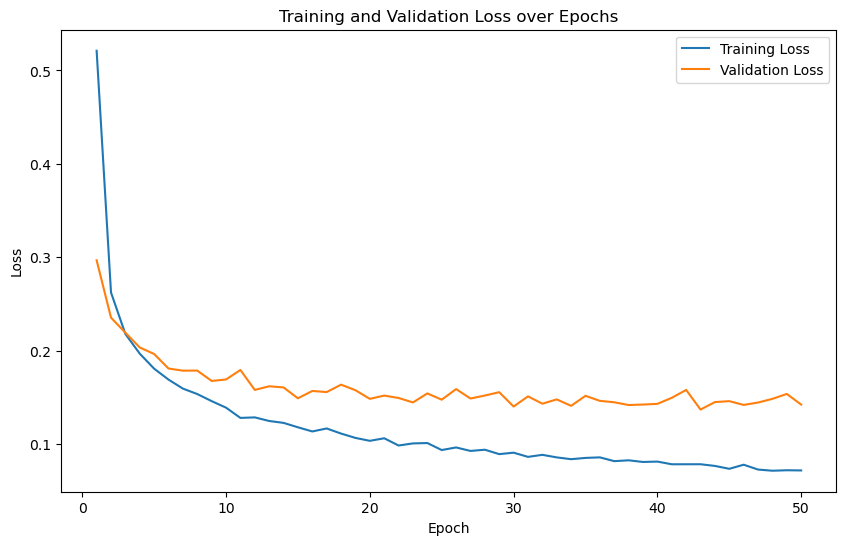

In [31]:
epochs_list = range(1, epochs + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs_list, train_losses, label='Training Loss')
plt.plot(epochs_list, val_losses, label='Validation Loss')
plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()